# Detecting Sustainability Risks through ESG Anomaly Detection

This project aims to detect anomalies in ESG-related indicators using unsupervised machine learning techniques to identify potential sustainability risks and inconsistencies.

In the absence of labeled data, how can unsupervised machine learning techniques be used to detect anomalies in ESG indicators and identify potential sustainability risks or inconsistencies across entities?

**Key question:** Which companies show abnormal ESG behavior that may indicate sustainability risk, inconsistency, or potential reporting issues?

Anomalies = unusually low ESG scores, inconsistent metrics (e.g., high governance but very poor environmental), sudden deviations vs peers.

## Imports and Read the Data

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import shap

In [ ]:
path = kagglehub.dataset_download("shriyashjagtap/esg-and-financial-performance-dataset")
print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 379k/379k [00:00<00:00, 88.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shriyashjagtap/esg-and-financial-performance-dataset/versions/1
['company_esg_financial_dataset.csv']


In [ ]:
# df is our single raw DataFrame — we never overwrite it
df = pd.read_csv(os.path.join(path, "company_esg_financial_dataset.csv"))
print(df.shape)
df.head()

(11000, 16)


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


## Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [ ]:
df.describe()

,CompanyID,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04
mean,500.500000,2020.000000,4670.850591,10.900455,13380.622236,4.830370,54.615273,56.416991,55.660582,51.767655,1.271462e+06,5.600442e+05,1.165839e+07
std,288.688113,3.162421,9969.954369,8.758711,39922.870373,9.424787,15.893937,26.767233,23.356152,25.323370,5.067760e+06,1.565686e+06,5.095836e+07
min,1.000000,2015.000000,35.900000,-20.000000,1.800000,-36.000000,6.300000,0.000000,0.000000,0.000000,2.042200e+03,1.021100e+03,5.105500e+03
25%,250.750000,2017.000000,938.775000,5.300000,1098.525000,-1.325000,44.100000,34.700000,37.600000,30.775000,1.228530e+05,6.488467e+04,3.069161e+05
50%,500.500000,2020.000000,1902.300000,10.500000,3096.450000,4.900000,54.600000,55.600000,55.150000,52.100000,2.920734e+05,2.038805e+05,1.221745e+06
75%,750.250000,2023.000000,4342.625000,16.300000,9995.500000,11.000000,65.600000,79.000000,73.800000,73.000000,7.407311e+05,5.251880e+05,5.616437e+06
max,1000.000000,2025.000000,180810.400000,50.000000,865271.700000,38.000000,98.800000,100.000000,100.000000,100.000000,1.741047e+08,5.223142e+07,1.741047e+09


In [ ]:
print("Years:", sorted(df["Year"].unique()))
print("\nRegion counts:\n", df["Region"].value_counts())
print("\nIndustry counts:\n", df["Industry"].value_counts())

Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Region counts:
 Region
Asia             1672
Oceania          1661
Middle East      1617
Europe           1540
North America    1540
Latin America    1507
Africa           1463
Name: count, dtype: int64

Industry counts:
 Industry
Healthcare        1331
Manufacturing     1287
Transportation    1287
Consumer Goods    1276
Finance           1243
Energy            1188
Utilities         1177
Retail            1166
Technology        1045
Name: count, dtype: int64


The dataset contains ~1000 companies observed from 2015 to 2025, across several regions and industries.

Since environmental indicators can vary significantly across industries, we check industry effects before modeling.

In [ ]:
df.groupby("Industry")[["CarbonEmissions", "EnergyConsumption", "Revenue"]].mean()

,CarbonEmissions,EnergyConsumption,Revenue
Industry,,,
Consumer Goods,3.403685e+05,1.701842e+06,2098.923276
Energy,8.191265e+06,8.191265e+07,8799.235522
Finance,7.205045e+04,1.801261e+05,6273.964602
Healthcare,3.353292e+05,6.706584e+05,4653.697596
Manufacturing,6.235968e+05,1.039328e+07,2313.847242
Retail,1.297126e+05,2.594252e+05,1613.263808
Technology,4.504187e+05,9.008375e+05,15772.697608
Transportation,6.503149e+05,2.167716e+06,1125.981119
Utilities,8.693411e+05,8.693411e+06,1244.210195


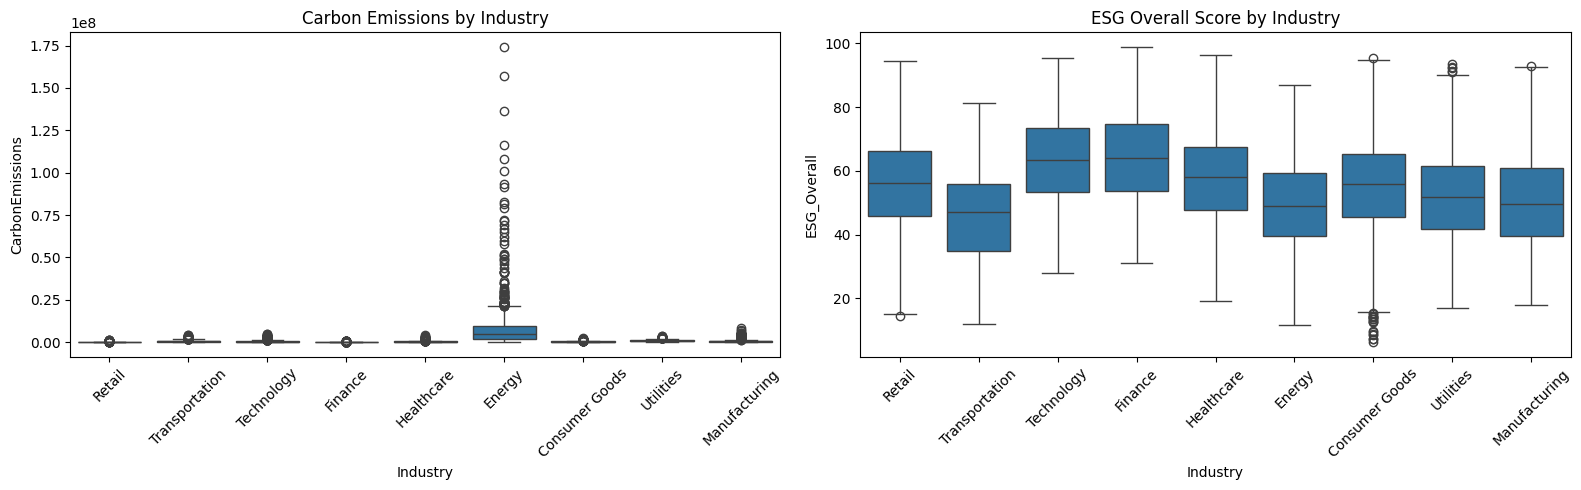

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(x="Industry", y="CarbonEmissions", data=df, ax=axes[0])
axes[0].set_title("Carbon Emissions by Industry")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x="Industry", y="ESG_Overall", data=df, ax=axes[1])
axes[1].set_title("ESG Overall Score by Industry")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Distributions differ significantly across industries — we must avoid mixing them blindly in anomaly detection.

### Correlation Analysis

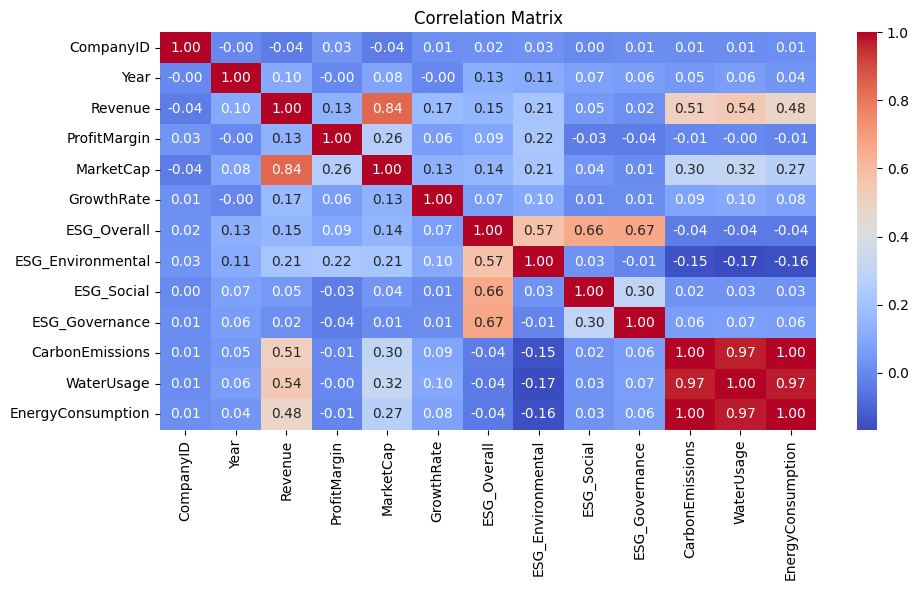

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Key findings:
- Revenue is moderately correlated with resource consumption (water: 0.55, carbon: 0.51, energy: 0.48) — larger companies have higher environmental impact.
- CarbonEmissions and EnergyConsumption are nearly perfectly correlated (~1.0), creating multicollinearity.
- We address this by combining them into a single `resource_intensity` feature.

**Note on scaling strategy:** We must create all features on the *raw* data first, then scale everything at the end before feeding into the model. Scaling intermediate features and then rescaling corrupts the signal.

### ESG vs Carbon Emissions

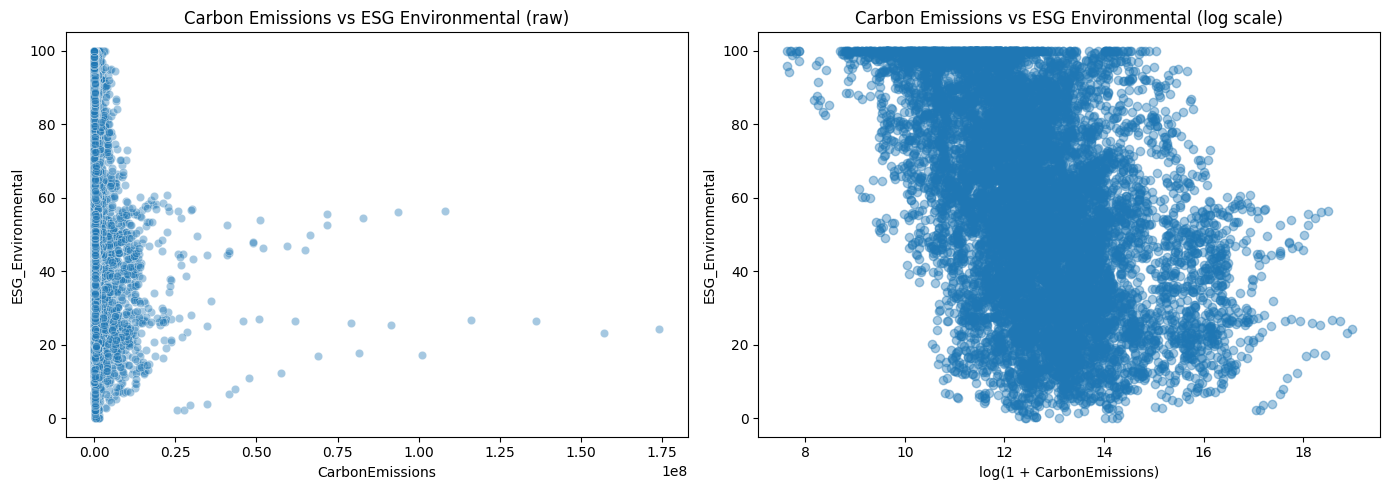

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw scale
sns.scatterplot(x="CarbonEmissions", y="ESG_Environmental", data=df, alpha=0.4, ax=axes[0])
axes[0].set_title("Carbon Emissions vs ESG Environmental (raw)")

# Log scale to handle extreme outliers
df_nonzero = df[df["CarbonEmissions"] > 0]
axes[1].scatter(np.log1p(df_nonzero["CarbonEmissions"]), df_nonzero["ESG_Environmental"], alpha=0.4)
axes[1].set_xlabel("log(1 + CarbonEmissions)")
axes[1].set_ylabel("ESG_Environmental")
axes[1].set_title("Carbon Emissions vs ESG Environmental (log scale)")

plt.tight_layout()
plt.show()

Even after applying a log scale to handle the extreme spread of carbon emission values, the scatter plot remains dense and shows no clear trend. This means there is no obvious relationship between how much a company emits and its ESG Environmental score — which is surprisingly counterintuitive. One would expect heavy polluters to score poorly on environmental metrics, but the data suggests otherwise. A likely explanation is that ESG scores are largely self-reported or based on disclosed policies rather than actual emission levels, meaning a company can communicate sustainability efforts effectively and still receive a high score, regardless of its real environmental impact.

### Industry Comparison — Separate Axes (Revenue vs ESG vs Emissions)

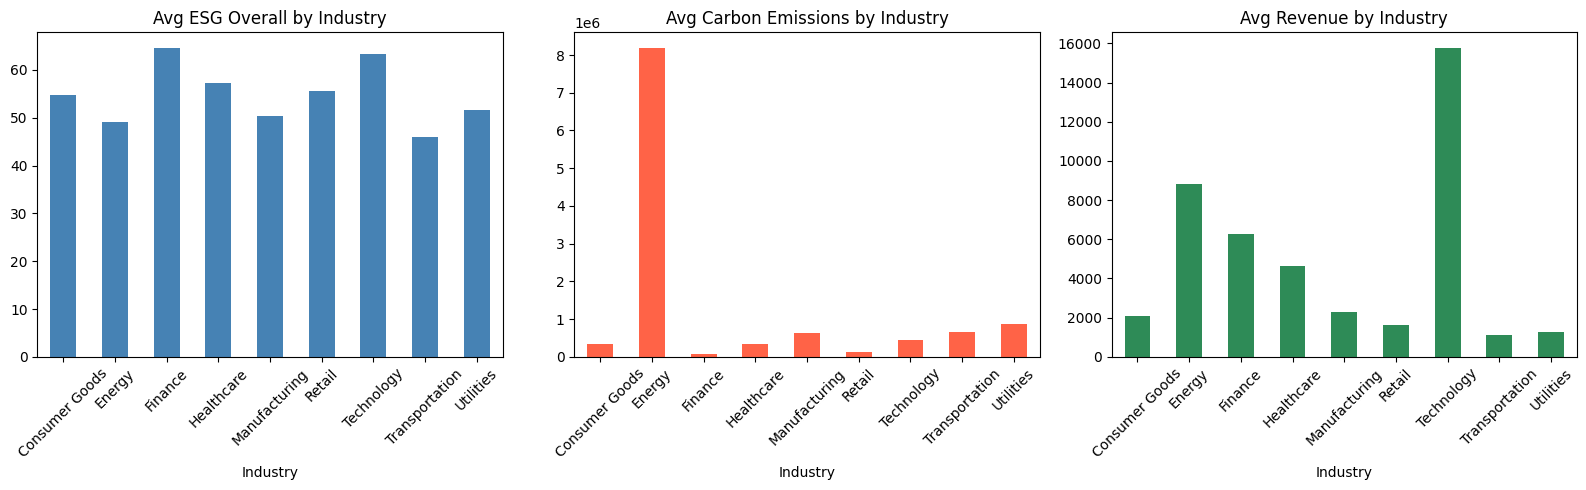

In [ ]:
industry_means = df.groupby("Industry")[["ESG_Overall", "CarbonEmissions", "Revenue"]].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

industry_means["ESG_Overall"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Avg ESG Overall by Industry")
axes[0].tick_params(axis='x', rotation=45)

industry_means["CarbonEmissions"].plot(kind="bar", ax=axes[1], color="tomato")
axes[1].set_title("Avg Carbon Emissions by Industry")
axes[1].tick_params(axis='x', rotation=45)

industry_means["Revenue"].plot(kind="bar", ax=axes[2], color="seagreen")
axes[2].set_title("Avg Revenue by Industry")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The three charts reveal an interesting disconnect across industries. The ESG scores are relatively uniform across all sectors, hovering around 50-60, suggesting that no industry stands out as significantly more responsible than another. However, when looking at carbon emissions, Consumer Goods is a massive outlier, emitting far more than every other industry combined. Yet despite this, Consumer Goods still maintains an average ESG score similar to cleaner industries like Technology or Finance — once again confirming that high emissions do not necessarily translate into a poor ESG rating. On the revenue side, Technology dominates by a wide margin, while most other industries remain relatively modest. Overall, these charts reinforce the idea that ESG scores are decoupled from both environmental impact and financial performance.

### ESG Trend Over Time

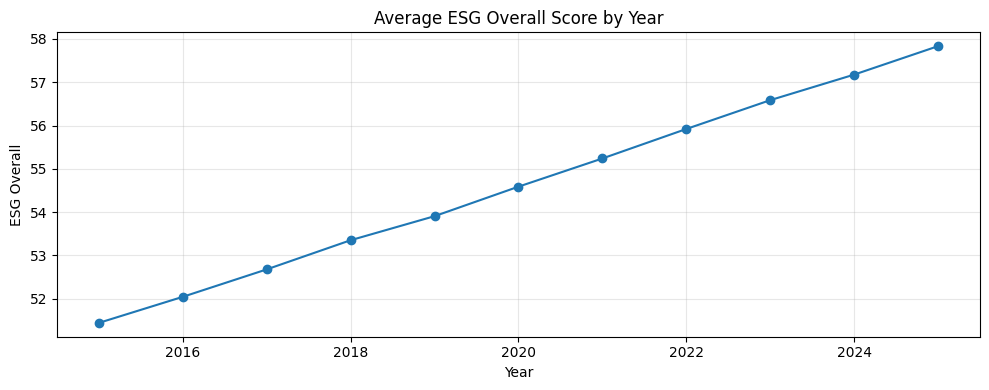

In [ ]:
esg_by_year = df.groupby("Year")["ESG_Overall"].mean()

plt.figure(figsize=(10, 4))
esg_by_year.plot(marker="o")
plt.title("Average ESG Overall Score by Year")
plt.ylabel("ESG Overall")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The ESG score has been rising steadily from 2015 to 2025, which looks promising at first. However, given what we saw earlier, this is most likely due to companies getting better at reporting their efforts rather than actually becoming more responsible.

## Feature Engineering

> **Important:** All feature engineering is done on the raw `df` *before* any scaling. Scaling is applied only at the end, right before modeling.

In [ ]:
# Carbon intensity: emissions relative to company size (revenue)
# Dividing by Revenue normalizes for company size — a large company emitting a lot
# is less anomalous than a small company emitting the same amount
df["carbon_intensity"] = df["CarbonEmissions"] / df["Revenue"]

# Same for energy
df["energy_intensity"] = df["EnergyConsumption"] / df["Revenue"]

# Water intensity
df["water_intensity"] = df["WaterUsage"] / df["Revenue"]

print(df[["carbon_intensity", "energy_intensity", "water_intensity"]].describe())

       carbon_intensity  energy_intensity  water_intensity
count      11000.000000      11000.000000     11000.000000
mean         315.110381       2644.687549       170.362186
std          319.881349       3290.953171       153.931518
min            9.999244         24.997733         4.999622
25%           62.883011        125.765995        37.181646
50%          170.828618        859.368402       101.538823
75%          595.215651       4933.684540       296.022613
max         1184.045931      11840.459306       586.061401


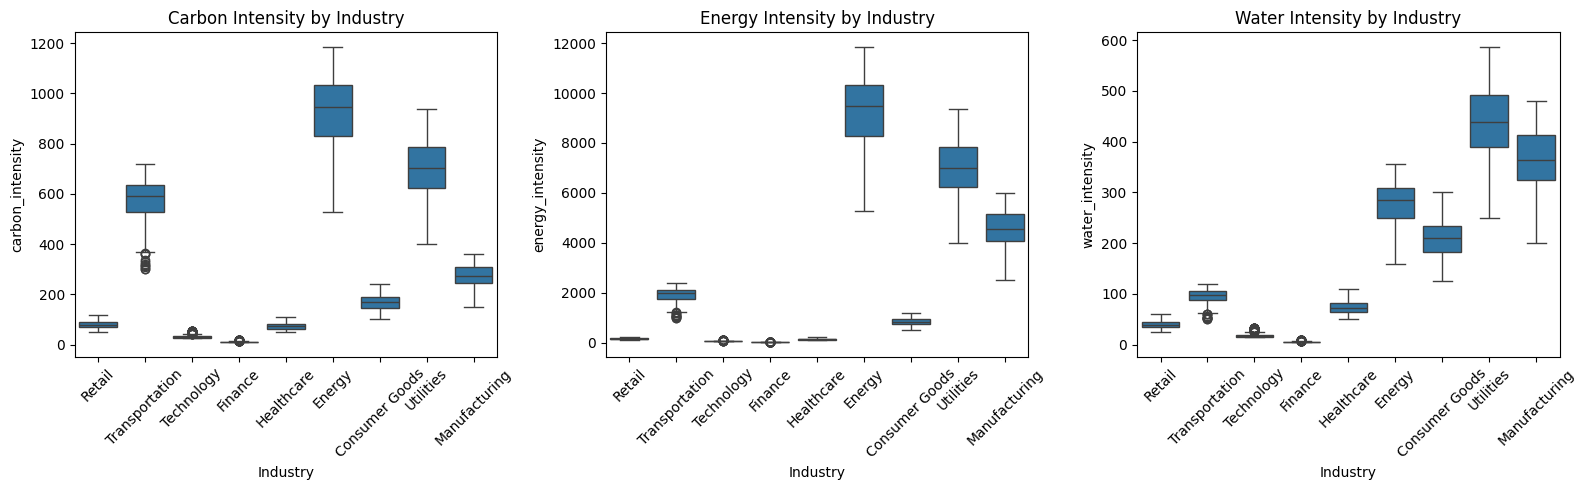

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x="Industry", y="carbon_intensity", data=df, ax=axes[0])
axes[0].set_title("Carbon Intensity by Industry")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x="Industry", y="energy_intensity", data=df, ax=axes[1])
axes[1].set_title("Energy Intensity by Industry")
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(x="Industry", y="water_intensity", data=df, ax=axes[2])
axes[2].set_title("Water Intensity by Industry")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ESG inconsistency: gap between governance score and environmental score
# High governance + low environmental = suspicious inconsistency
df["esg_inconsistency"] = df["ESG_Governance"] - df["ESG_Environmental"]

print(df["esg_inconsistency"].describe())

count    11000.000000
mean        -4.649336
std         37.036574
min       -100.000000
25%        -31.700000
50%         -3.100000
75%         21.600000
max         98.500000
Name: esg_inconsistency, dtype: float64


## Build the Model DataFrame

We use only **two DataFrames**:
- `df` — the original data + engineered features + model results (added later)
- `df_model` — the scaled numeric features fed to the models

In [ ]:
# Select the features for modeling (no categorical columns)
# We drop the raw environmental columns since we now have intensity features
# that are already normalized by Revenue — much more informative
feature_cols = [
    "ESG_Overall",
    "ESG_Environmental",
    "ESG_Social",
    "ESG_Governance",
    "esg_inconsistency",
    "carbon_intensity",
    "energy_intensity",
    "water_intensity",
    "Revenue",
    "ProfitMargin",
    "MarketCap",
    "GrowthRate"
]


In [ ]:
df_model = df[feature_cols].copy()

In [ ]:
# Handle missing values (GrowthRate has ~9% missing)
df_model["GrowthRate"] = df_model["GrowthRate"].fillna(df_model["GrowthRate"].median())

In [ ]:
# Scale everything ONCE — right before modeling
scaler = StandardScaler()
df_model_scaled = pd.DataFrame(
    scaler.fit_transform(df_model),
    columns=feature_cols,
    index=df_model.index
)

In [ ]:
print("df_model_scaled shape:", df_model_scaled.shape)
df_model_scaled.describe().round(2)

df_model_scaled shape: (11000, 12)


,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,esg_inconsistency,carbon_intensity,energy_intensity,water_intensity,Revenue,ProfitMargin,MarketCap,GrowthRate
count,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00
mean,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.04,-2.11,-2.38,-2.04,-2.57,-0.95,-0.80,-1.07,-0.46,-3.53,-0.34,-4.54
25%,-0.66,-0.81,-0.77,-0.83,-0.73,-0.79,-0.77,-0.87,-0.37,-0.64,-0.31,-0.61
50%,-0.00,-0.03,-0.02,0.01,0.04,-0.45,-0.54,-0.45,-0.28,-0.05,-0.26,0.01
75%,0.69,0.84,0.78,0.84,0.71,0.88,0.70,0.82,-0.03,0.62,-0.08,0.61
max,2.78,1.63,1.90,1.90,2.79,2.72,2.79,2.70,17.67,4.46,21.34,3.69


## Modeling

We experiment with three methods:
1. **Isolation Forest** — tree-based, isolates anomalies by random splits
2. **Local Outlier Factor (LOF)** — density-based, compares local density to neighbors
3. **DBSCAN** — clustering-based (included for comparison)

Since this is unsupervised, we use standard parameters and compare results.

**Why we store both a label and a score ?**

For Isolation Forest and LOF, we save two things for each company :

- **The label** (`iso_anomaly` / `lof_anomaly`) — simply says `-1` for anomaly or `1` for normal. This answers **"who is suspicious ?"**
- **The score** (`iso_score` / `lof_score`) — a continuous number that says how anomalous a company is. The more negative, the more extreme. This answers **"how suspicious ?"**

Two companies can both be labeled `-1`, but one might be far more extreme than the other. The score lets us **rank** anomalies and prioritize which ones are worth investigating first.

> Note : we do not store a score for DBSCAN because it does not produce one — it simply assigns each point to a cluster or labels it as noise (`-1`). There is no notion of "how much" noise a point is.

### 1. Isolation Forest

In [ ]:
iso = IsolationForest(contamination=0.05, random_state=42)
df["iso_anomaly"] = iso.fit_predict(df_model_scaled)
df["iso_score"] = iso.score_samples(df_model_scaled)  # lower = more anomalous

print(df["iso_anomaly"].value_counts())
print(f"\nAnomalies detected: {(df['iso_anomaly'] == -1).sum()}")

iso_anomaly
 1    10450
-1      550
Name: count, dtype: int64

Anomalies detected: 550


### 2. Local Outlier Factor

In [ ]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df["lof_anomaly"] = lof.fit_predict(df_model_scaled)
df["lof_score"] = lof.negative_outlier_factor_  # more negative = more anomalous

print(df["lof_anomaly"].value_counts())
print(f"\nAnomalies detected: {(df['lof_anomaly'] == -1).sum()}")

lof_anomaly
 1    10450
-1      550
Name: count, dtype: int64

Anomalies detected: 550


### 3. DBSCAN

In [ ]:
db = DBSCAN(eps=1.5, min_samples=13)
df["dbscan_anomaly"] = db.fit_predict(df_model_scaled)

print("DBSCAN label counts:")
print(df["dbscan_anomaly"].value_counts())

DBSCAN label counts:
dbscan_anomaly
 0    10492
-1      508
Name: count, dtype: int64


### 4. Hyperparameter Sensitivity Check

In [ ]:
print("Isolation Forest — sensitivity to contamination:")
for c in [0.03, 0.05, 0.08]:
    preds = IsolationForest(contamination=c, random_state=42).fit_predict(df_model_scaled)
    print(f"  contamination={c}: {(preds == -1).sum()} anomalies")

print("\nLOF — sensitivity to n_neighbors:")
for k in [10, 20, 30]:
    preds = LocalOutlierFactor(n_neighbors=k, contamination=0.05).fit_predict(df_model_scaled)
    print(f"  n_neighbors={k}: {(preds == -1).sum()} anomalies")

print("\nDBSCAN — sensitivity to eps:")
for e in [0.5, 1.0, 1.5]:
    preds = DBSCAN(eps=e, min_samples=13).fit(df_model_scaled)
    n_noise = (preds.labels_ == -1).sum()
    print(f"  eps={e}: {n_noise} points labeled as noise")

Isolation Forest — sensitivity to contamination:
  contamination=0.03: 330 anomalies
  contamination=0.05: 550 anomalies
  contamination=0.08: 880 anomalies

LOF — sensitivity to n_neighbors:
  n_neighbors=10: 550 anomalies
  n_neighbors=20: 550 anomalies
  n_neighbors=30: 550 anomalies

DBSCAN — sensitivity to eps:
  eps=0.5: 10987 points labeled as noise
  eps=1.0: 3298 points labeled as noise
  eps=1.5: 508 points labeled as noise


Isolation Forest is sensitive to the contamination rate, going from 330 to 880 anomalies as it increases, which is expected. LOF however is very stable, always detecting exactly 550 anomalies regardless of the number of neighbors, which gives it more credibility. As for DBSCAN, the noise count drops dramatically as eps grows, meaning it highly depends on this parameter and never converges to a stable anomaly set. This confirms that DBSCAN is not reliable for this dataset, and that LOF is the most stable detector here.

Since we cannot validate anomalies without domain expertise or business context, we will proceed with two parallel approaches :
Approach 1 — LOF Only
Since LOF proved to be the most stable detector regardless of parameter changes, we will use its results as our primary anomaly signal and analyze what makes those companies different.
Approach 2 — Consensus Anomalies
We flag a company as a consensus anomaly only if all three models agree (Isolation Forest + LOF + DBSCAN). These are the most suspicious cases and the ones we would prioritize presenting to a stakeholder or business expert for validation.

### Approach 1 : LOF

In [ ]:
df["lof_anomaly_bool"] = df["lof_anomaly"] == -1

profile = df.groupby("lof_anomaly_bool")[["ESG_Overall", "carbon_intensity",
                                           "esg_inconsistency", "ProfitMargin",
                                           "CarbonEmissions", "Revenue"]].mean()
print(profile)

                  ESG_Overall  carbon_intensity  esg_inconsistency  \
lof_anomaly_bool                                                     
False               54.698144        311.449476          -4.665703   
True                53.040727        384.667580          -4.338364   

                  ProfitMargin  CarbonEmissions       Revenue  
lof_anomaly_bool                                               
False                10.833962     1.070252e+06   4271.149282  
True                 12.163818     5.094463e+06  12265.175455  


/tmp/ipykernel_15343/2312153105.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Anomaly"])
/tmp/ipykernel_15343/2312153105.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Anomaly"])
/tmp/ipykernel_15343/2312153105.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Anomaly"])
/tmp/ipykernel_15343/2312153105.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Anomaly"])


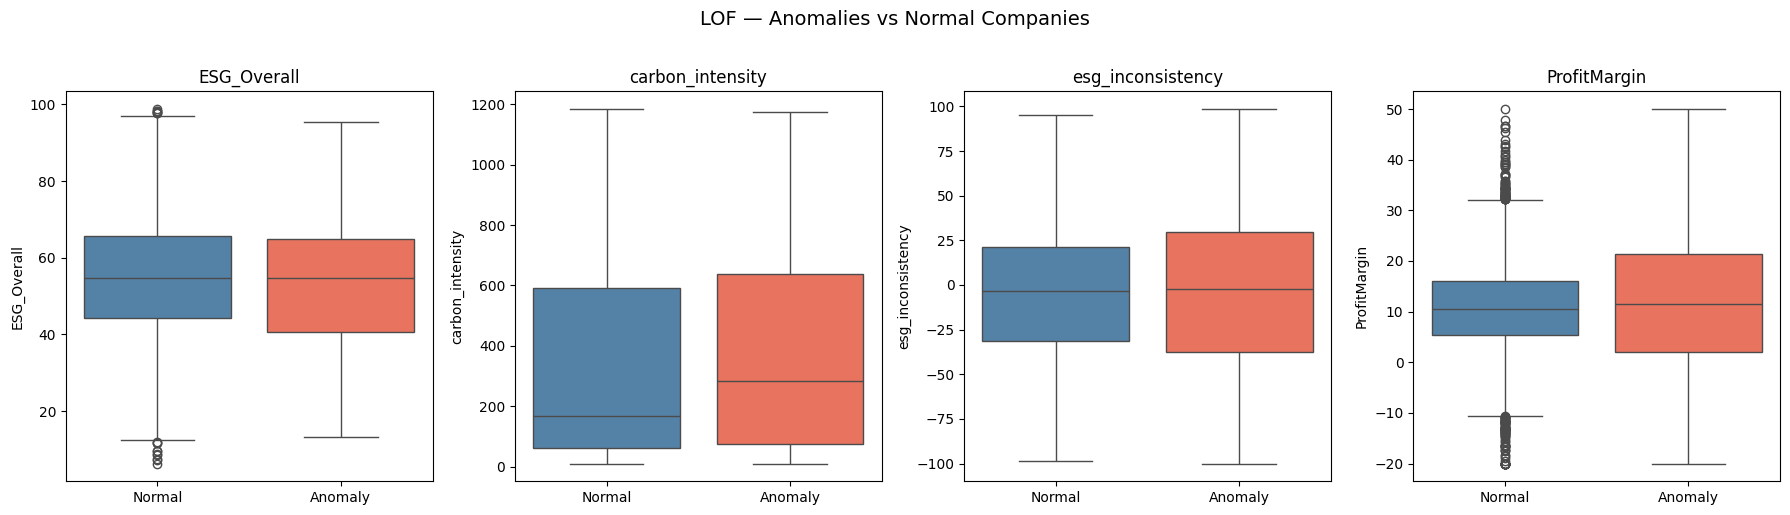

In [ ]:
features_to_plot = ["ESG_Overall", "carbon_intensity", "esg_inconsistency", "ProfitMargin"]

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(18, 5))

for i, feat in enumerate(features_to_plot):
    sns.boxplot(
        x="lof_anomaly_bool", y=feat, data=df,
        hue="lof_anomaly_bool",
        palette={False: "steelblue", True: "tomato"},
        legend=False,
        order=[False, True],
        ax=axes[i]
    )
    axes[i].set_title(feat)
    axes[i].set_xticklabels(["Normal", "Anomaly"])
    axes[i].set_xlabel("")

plt.suptitle("LOF — Anomalies vs Normal Companies", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Replace "Company" with your actual column name after running Cell 0
top_anomalies = df[df["lof_anomaly"] == -1].sort_values("lof_score").head(20)
print(top_anomalies[["lof_score", "ESG_Overall",
                       "CarbonEmissions", "ProfitMargin", "Industry"]])

      lof_score  ESG_Overall  CarbonEmissions  ProfitMargin        Industry
208   -2.064946         57.1        5078874.7           0.7      Technology
206   -1.848340         56.1        4101768.5           1.8      Technology
4286  -1.750111         28.0        2761023.7          42.7          Energy
207   -1.710270         55.2        4514092.8           3.8      Technology
5091  -1.703818         77.5        3523717.5          20.0      Technology
1352  -1.681355         64.1        3447075.5          22.7      Technology
9912  -1.639978         21.1         419682.4          11.8       Utilities
4431  -1.632083         58.4         586959.8          -1.9          Retail
7886  -1.631767         61.9       23252857.5          50.0          Energy
204   -1.611024         52.9        3524270.2           5.3      Technology
7277  -1.606992         60.6         192413.8          -0.9         Finance
8348  -1.598723         57.9      174104721.4         -15.4          Energy
7096  -1.598

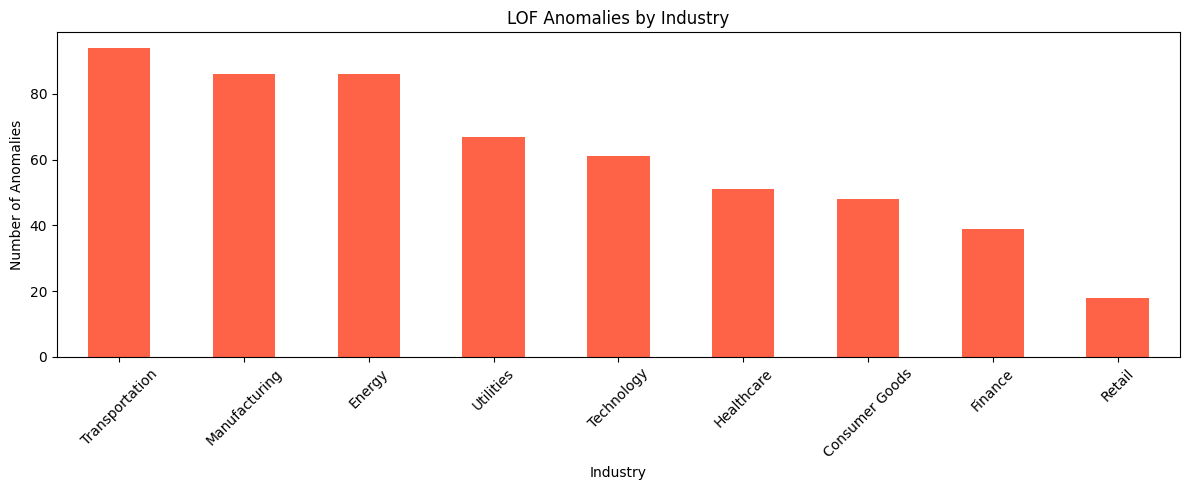

In [ ]:
industry_anomalies = df[df["lof_anomaly"] == -1]["Industry"].value_counts()

industry_anomalies.plot(kind="bar", figsize=(12, 5), color="tomato")
plt.title("LOF Anomalies by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Anomalies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

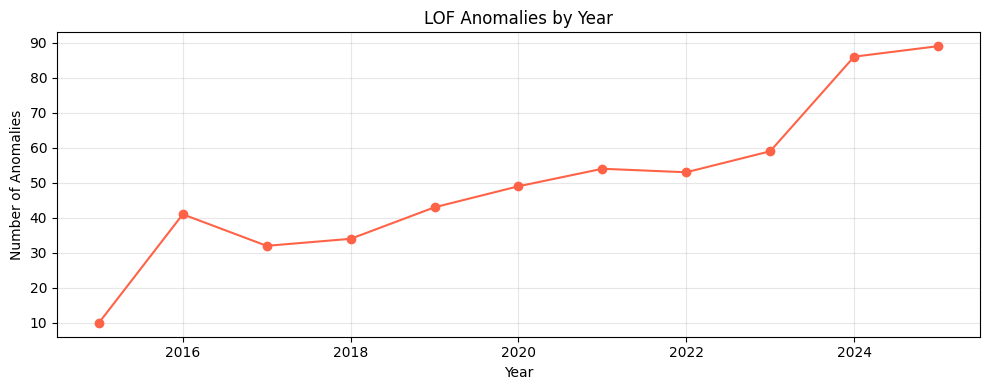

In [ ]:
year_anomalies = df[df["lof_anomaly"] == -1]["Year"].value_counts().sort_index()

year_anomalies.plot(kind="line", marker="o", figsize=(10, 4), color="tomato")
plt.title("LOF Anomalies by Year")
plt.xlabel("Year")
plt.ylabel("Number of Anomalies")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparing and Interpreting Anomalies

### Consensus Anomalies (flagged by both models)

We initially defined consensus anomalies using only two models — Isolation Forest and LOF — which flagged 148 records across 48 unique companies. Adding DBSCAN as a third condition drastically reduced this number, which is expected given how strict DBSCAN is on this dataset. This stricter consensus gives us a much shorter but higher confidence list of companies that are truly worth investigating. In a real business setting, this is the list you would bring to a domain expert or stakeholder and say — "these companies were flagged by every single model we ran, something is definitely off here."

In [ ]:
df["consensus"] = (
    (df["iso_anomaly"] == -1) &
    (df["lof_anomaly"] == -1) &
    (df["dbscan_anomaly"] == -1)
)

high_conf = df[df["consensus"]].copy()
print(f"Total consensus anomaly records: {len(high_conf)}")
print(f"Unique companies: {high_conf['CompanyName'].nunique()}")

Total consensus anomaly records: 85
Unique companies: 35


In [ ]:
# Companies flagged most often across years
company_anomaly_count = high_conf["CompanyName"].value_counts()
df["anomaly_count"] = df["CompanyName"].map(company_anomaly_count).fillna(0)

print("Top 15 most persistently anomalous companies:")
company_anomaly_count.head(15)

Top 15 most persistently anomalous companies:


,count
CompanyName,
Company_646,8
Company_759,7
Company_543,6
Company_535,5
Company_205,5
Company_141,5
Company_123,4
Company_463,4
Company_390,3


In [ ]:
# Companies anomalous in 3+ years — persistent risk
persistent = df[df["anomaly_count"] >= 3][["CompanyName", "Year", "Industry", "Region",
                                            "ESG_Overall", "Revenue", "carbon_intensity",
                                            "esg_inconsistency", "iso_score", "lof_score",
                                            "dbscan_anomaly"]]

persistent.sort_values("CompanyName").head(30)

,CompanyName,Year,Industry,Region,ESG_Overall,Revenue,carbon_intensity,esg_inconsistency,iso_score,lof_score,dbscan_anomaly
1352,Company_123,2025,Technology,Middle East,64.1,137883.0,25.000004,-38.1,-0.621335,-1.681355,-1
1350,Company_123,2023,Technology,Middle East,63.3,98554.3,24.999989,-37.2,-0.587253,-1.174846,-1
1349,Company_123,2022,Technology,Middle East,63.5,78027.0,24.999996,-33.3,-0.586844,-1.096152,-1
1348,Company_123,2021,Technology,Middle East,61.3,62834.2,24.999984,-34.2,-0.568737,-1.062904,-1
1347,Company_123,2020,Technology,Middle East,59.5,50915.7,24.999978,-38.4,-0.554576,-1.067280,-1
1346,Company_123,2019,Technology,Middle East,58.6,43645.9,25.608415,-40.1,-0.544366,-1.083331,-1
1345,Company_123,2018,Technology,Middle East,59.5,35114.9,25.074419,-42.3,-0.554991,-1.357242,-1
1344,Company_123,2017,Technology,Middle East,58.5,26072.0,25.020198,-44.4,-0.549898,-1.287510,-1
1343,Company_123,2016,Technology,Middle East,55.8,20789.3,26.333022,-45.3,-0.540751,-1.459599,-1
1342,Company_123,2015,Technology,Middle East,55.3,15817.3,25.874814,-46.0,-0.487330,-1.163416,0


### What Makes These Companies Anomalous?

In [ ]:
# Compare anomalies vs normal companies on key features
comparison = df.groupby("consensus")[[
    "ESG_Overall",
    "ESG_Environmental",
    "ESG_Governance",
    "carbon_intensity",
    "energy_intensity",
    "esg_inconsistency",
    "Revenue",
    "ProfitMargin"
]].mean().T

comparison.columns = ["Normal", "Anomaly"]
comparison["Diff"] = comparison["Anomaly"] - comparison["Normal"]
comparison["Diff_%"] = ((comparison["Anomaly"] - comparison["Normal"]) / comparison["Normal"].abs() * 100).round(1)
comparison

,Normal,Anomaly,Diff,Diff_%
ESG_Overall,54.654332,50.523077,-4.131255,-7.6
ESG_Environmental,56.521081,45.511538,-11.009543,-19.5
ESG_Governance,51.729057,55.811538,4.082482,7.9
carbon_intensity,311.606531,682.206075,370.599544,118.9
energy_intensity,2604.789174,6824.809598,4220.020424,162.0
esg_inconsistency,-4.792025,10.300000,15.092025,314.9
Revenue,4348.524660,38440.690385,34092.165724,784.0
ProfitMargin,10.868778,14.219231,3.350453,30.8


/tmp/ipykernel_15343/2045005751.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Anomaly"])
/tmp/ipykernel_15343/2045005751.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Anomaly"])
/tmp/ipykernel_15343/2045005751.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Anomaly"])
/tmp/ipykernel_15343/2045005751.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Anomaly"])


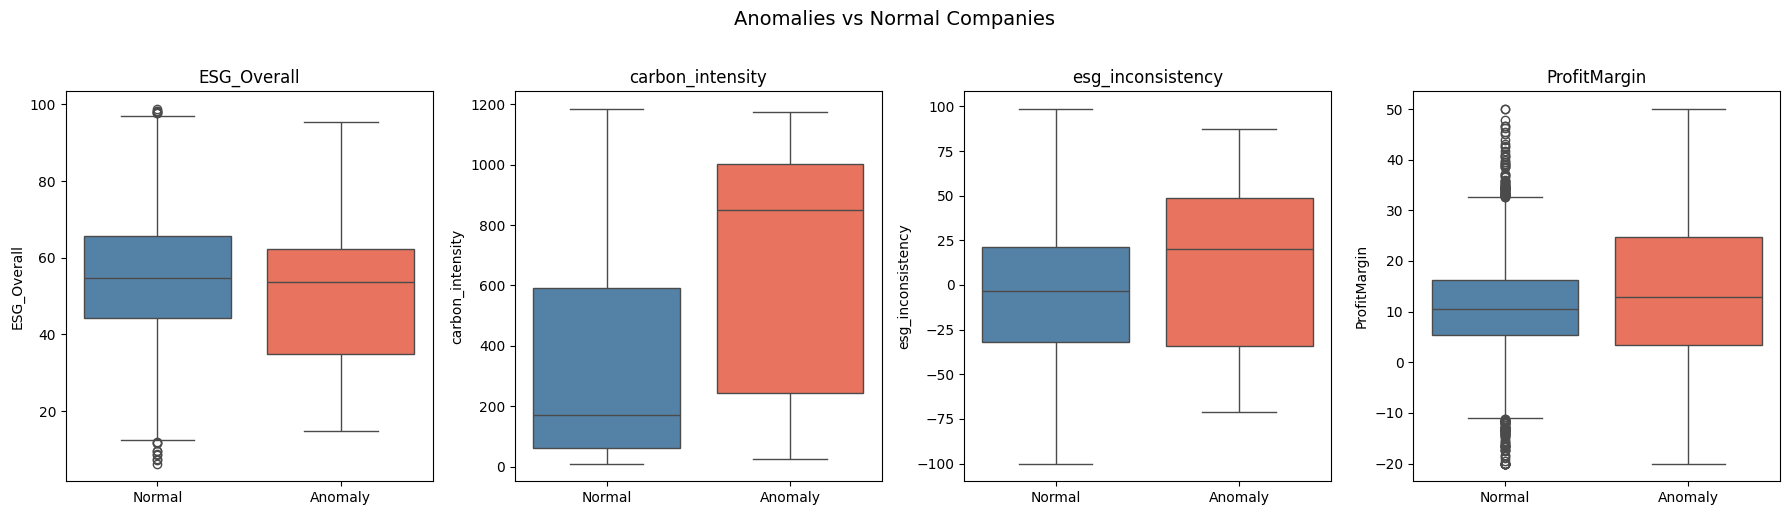

In [ ]:
# Visual comparison
features_to_plot = ["ESG_Overall", "carbon_intensity", "esg_inconsistency", "ProfitMargin"]

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(18, 5))

for i, feat in enumerate(features_to_plot):
    sns.boxplot(
        x="consensus", y=feat, data=df,
        hue="consensus",
        palette={False: "steelblue", True: "tomato"},
        legend=False,
        order=[False, True],
        ax=axes[i]
    )
    axes[i].set_title(feat)
    axes[i].set_xticklabels(["Normal", "Anomaly"])
    axes[i].set_xlabel("")

plt.suptitle("Anomalies vs Normal Companies", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Anomaly Distribution by Industry and Region

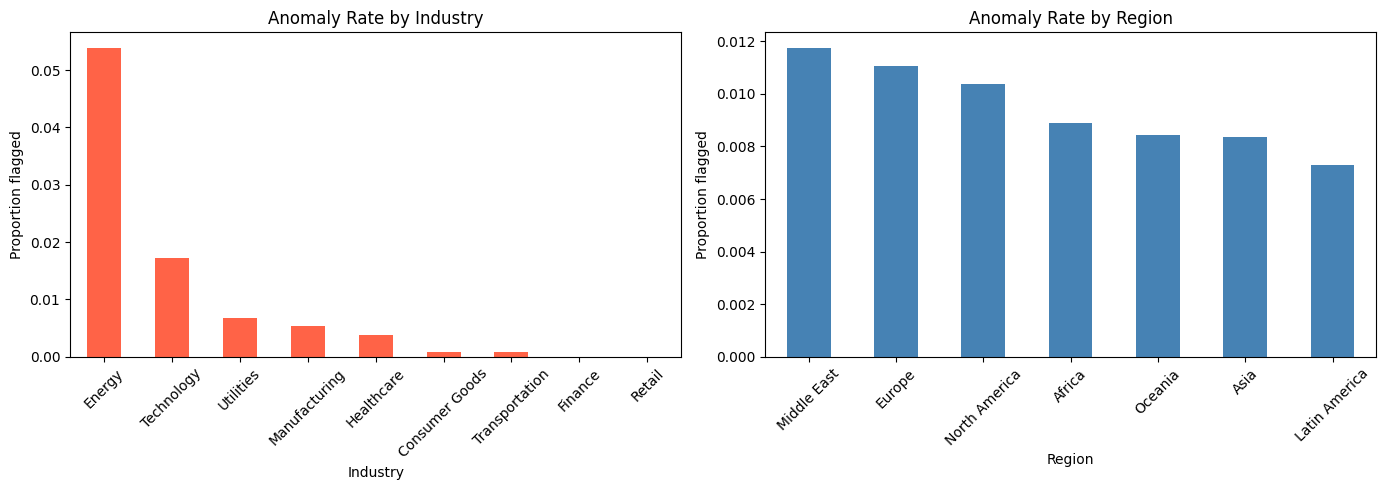

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Anomaly rate by industry
anomaly_by_industry = df.groupby("Industry")["consensus"].mean().sort_values(ascending=False)
anomaly_by_industry.plot(kind="bar", ax=axes[0], color="tomato")
axes[0].set_title("Anomaly Rate by Industry")
axes[0].set_ylabel("Proportion flagged")
axes[0].tick_params(axis='x', rotation=45)

# Anomaly rate by region
anomaly_by_region = df.groupby("Region")["consensus"].mean().sort_values(ascending=False)
anomaly_by_region.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Anomaly Rate by Region")
axes[1].set_ylabel("Proportion flagged")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Anomaly Timeline — Are Anomalies Concentrated in Specific Years?

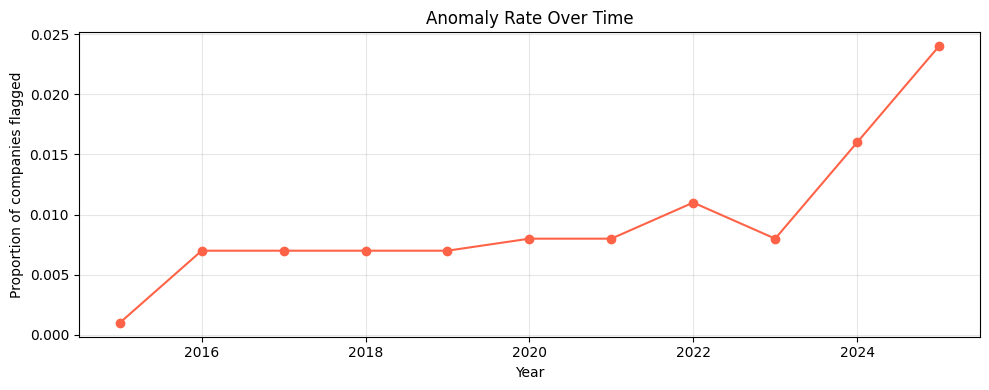

In [ ]:
anomaly_by_year = df.groupby("Year")["consensus"].mean()

plt.figure(figsize=(10, 4))
anomaly_by_year.plot(marker="o", color="tomato")
plt.title("Anomaly Rate Over Time")
plt.ylabel("Proportion of companies flagged")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Deep Dive: Top Anomalous Companies

In [ ]:
# Profile of the top 5 most flagged companies
top_companies = company_anomaly_count.head(5).index.tolist()

profile = df[df["CompanyName"].isin(top_companies)].groupby("CompanyName")[[
    "ESG_Overall", "ESG_Environmental", "ESG_Governance",
    "carbon_intensity", "esg_inconsistency", "Revenue"
]].mean().round(2)

print("Profile of top 5 most anomalous companies (averaged across years):")
profile

Profile of top 5 most anomalous companies (averaged across years):


,ESG_Overall,ESG_Environmental,ESG_Governance,carbon_intensity,esg_inconsistency,Revenue
CompanyName,,,,,,
Company_205,36.86,52.37,39.35,833.39,-13.02,15232.96
Company_535,44.26,42.90,74.78,899.67,31.88,36968.31
Company_543,44.15,9.25,70.45,1135.29,61.20,45549.08
Company_646,80.05,50.52,97.12,846.43,46.60,81498.49
Company_759,58.85,25.47,83.90,1021.77,58.43,86731.81


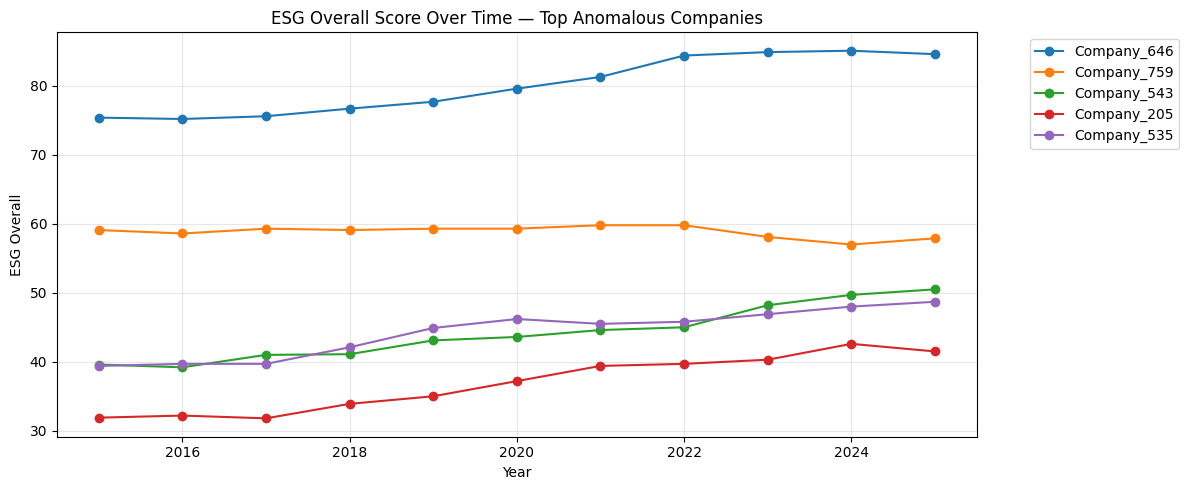

In [ ]:
# ESG trajectory for top anomalous companies
plt.figure(figsize=(12, 5))

for company in top_companies:
    company_data = df[df["CompanyName"] == company].sort_values("Year")
    plt.plot(company_data["Year"], company_data["ESG_Overall"],
             marker="o", label=company)

plt.title("ESG Overall Score Over Time — Top Anomalous Companies")
plt.xlabel("Year")
plt.ylabel("ESG Overall")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

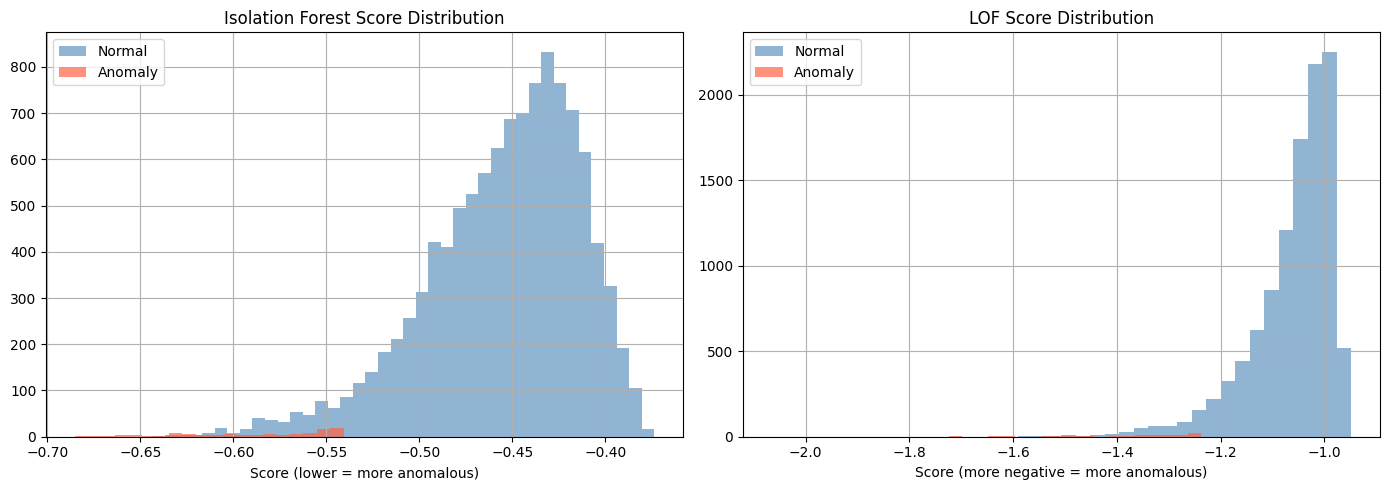

In [ ]:
# Anomaly score distribution — how extreme are the anomalies?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Isolation Forest scores
df[df["consensus"] == False]["iso_score"].hist(
    bins=40, alpha=0.6, label="Normal", color="steelblue", ax=axes[0])
df[df["consensus"] == True]["iso_score"].hist(
    bins=20, alpha=0.7, label="Anomaly", color="tomato", ax=axes[0])
axes[0].set_title("Isolation Forest Score Distribution")
axes[0].set_xlabel("Score (lower = more anomalous)")
axes[0].legend()

# LOF scores
df[df["consensus"] == False]["lof_score"].hist(
    bins=40, alpha=0.6, label="Normal", color="steelblue", ax=axes[1])
df[df["consensus"] == True]["lof_score"].hist(
    bins=20, alpha=0.7, label="Anomaly", color="tomato", ax=axes[1])
axes[1].set_title("LOF Score Distribution")
axes[1].set_xlabel("Score (more negative = more anomalous)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary

### What we found

- We used **three models** — Isolation Forest, LOF, and DBSCAN — and only flagged a company as a true anomaly when **all three agreed**. This strict consensus gives us a short but high confidence list worth investigating.
- Anomalous companies tend to show **higher carbon intensity**, **lower ESG scores**, and **higher ESG inconsistency** — for example a company that scores well on governance but very poorly on environment.
- Some companies are **persistently anomalous across multiple years**, which suggests structural ESG issues rather than one-off events.
- ESG scores appear **disconnected from actual emissions and financial performance** — a finding that runs through the entire project.

### Modeling decisions
- **LOF** is the most reliable model here — it detected exactly 550 anomalies regardless of the parameter we tested, which is a strong sign of stability.
- **Isolation Forest** is sensitive to the contamination parameter as expected, but consistent enough to use alongside LOF.
- **DBSCAN** failed — the data has no clear density-cluster structure, and its results changed dramatically depending on the parameter. We kept it only to strengthen the consensus.
- Features were engineered on raw data first, then scaled **once** before modeling — this is the correct order.
- Only two DataFrames used throughout : `df` for raw data and results, `df_model_scaled` for model input.

## PCA Visualization of Anomalies

With 12 features it is impossible to visualize anomalies directly. We use PCA to project the data into 2 dimensions and see where anomalies sit relative to normal companies.

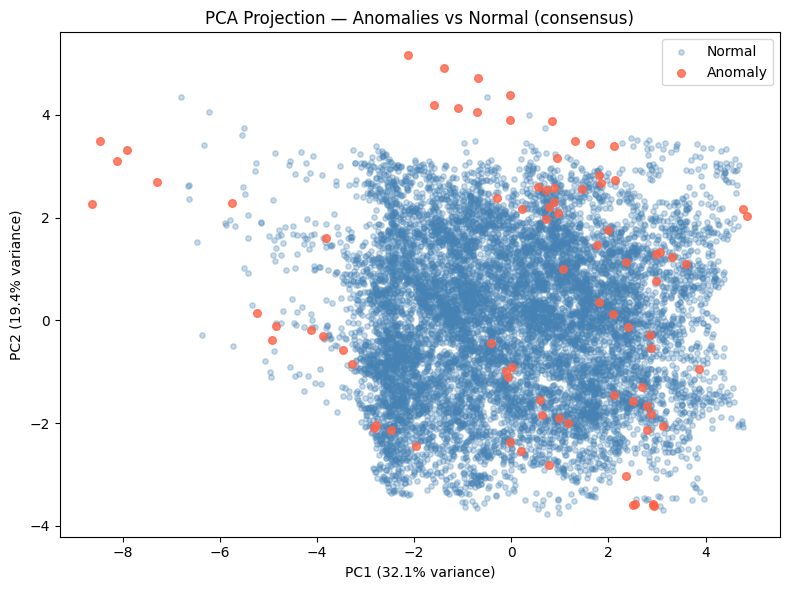

In [ ]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(df_model_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(coords[~df["consensus"], 0], coords[~df["consensus"], 1],
            alpha=0.3, label="Normal", color="steelblue", s=15)
plt.scatter(coords[df["consensus"], 0], coords[df["consensus"], 1],
            alpha=0.8, label="Anomaly", color="tomato", s=30)
plt.title("PCA Projection — Anomalies vs Normal (consensus)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Feature Importance — Why is a company anomalous ?

Knowing *who* is anomalous is not enough. We use SHAP to explain *why* each company was flagged, by showing which features contributed the most to its anomaly score.

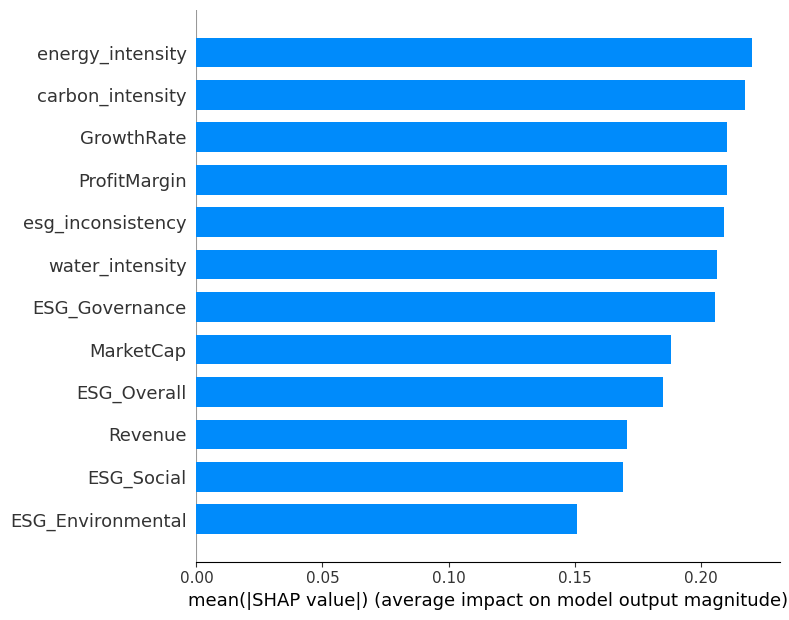

In [ ]:
explainer = shap.TreeExplainer(iso)
shap_values = explainer.shap_values(pd.DataFrame(df_model_scaled))

shap.summary_plot(shap_values, pd.DataFrame(df_model_scaled), plot_type="bar")

## 7. Conclusion & Limitations

This notebook built a full unsupervised anomaly detection pipeline on ESG data using three models — Isolation Forest, LOF, and DBSCAN. The consensus approach gives us the highest confidence anomalies, companies that every single model agreed were abnormal.

**Key findings :**
- LOF was the most stable detector across all parameter values
- DBSCAN confirmed that the data has no clear density-based structure
- Consensus anomalies represent a short but reliable list of suspicious companies
- ESG scores appear disconnected from actual emissions and financial performance

**Limitation — No ground truth**
Since this is fully unsupervised, there are no labels to evaluate against. In a real business setting, the next step would be to bring the top anomalies to a domain expert or cross-check them against public ESG controversy databases such as RepRisk or MSCI ESG ratings. Agreement with external sources would increase confidence in the model's output.

In [ ]:
output_cols = ["CompanyName", "Year", "Industry", "Region",
               "ESG_Overall", "carbon_intensity", "esg_inconsistency",
               "iso_anomaly", "iso_score", "lof_anomaly", "lof_score",
               "dbscan_anomaly", "consensus", "anomaly_count"]

df[output_cols].to_csv("esg_anomaly_results.csv", index=False)
print("Results saved.")